# DATA LOADING

In [1]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from category_encoders import TargetEncoder
import warnings
from sklearn.preprocessing import OneHotEncoder
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path  = '/content/drive/MyDrive/Internship BCC/df_merged.csv'
# path = '/content/drive/MyDrive/Modeling Internship BCC/df_merged.csv'
df = pd.read_csv(path)
display(df)

,price,date_of_transfer,postcode,property_type,old_new,duration,street,town_city,district,county,ppd_category_type,year,district_clean,Area (sq km),Estimated Population mid-2024,2024 people per sq. km,area_type
0,280000,2022-06-06,B78 3XA,D,N,F,WESTMORLAND CLOSE,TAMWORTH,TAMWORTH,STAFFORDSHIRE,A,2022,TAMWORTH,31,81117,2630,Urban
1,312500,2022-06-20,ST7 4JZ,D,N,F,SANDS ROAD,STOKE-ON-TRENT,NEWCASTLE-UNDER-LYME,STAFFORDSHIRE,A,2022,NEWCASTLEUNDERLYME,211,127727,605,Urban
2,150000,2022-06-30,ST14 7QG,S,N,F,LAMBERT ROAD,UTTOXETER,EAST STAFFORDSHIRE,STAFFORDSHIRE,A,2022,EAST STAFFFORDSHIRE,387,129659,335,Urban
3,515000,2022-05-25,B78 3UG,D,N,F,MOAT DRIVE,TAMWORTH,LICHFIELD,STAFFORDSHIRE,A,2022,LICHFIELD,331,111932,338,Urban
4,262500,2022-07-15,ST20 0HY,D,N,F,HOLLIES BROOK CLOSE,STAFFORD,STAFFORD,STAFFORDSHIRE,A,2022,STAFFFORD,598,141556,237,Rural
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3629275,875000,2026-01-15,RG41 4XJ,D,N,F,JAPONICA CLOSE,WOKINGHAM,WOKINGHAM,WOKINGHAM,A,2026,WOKINGHAM,179,187200,1046,Urban
3629276,370000,2026-01-14,RG20 6QQ,T,N,F,MEADOW CLOSE,NEWBURY,WEST BERKSHIRE,WEST BERKSHIRE,A,2026,WEST BERKSHIRE,704,165112,234,Rural
3629277,700000,2026-01-15,SL3 9NQ,S,N,F,FAIRFIELD AVENUE,SLOUGH,WINDSOR AND MAIDENHEAD,WINDSOR AND MAIDENHEAD,A,2026,WINDSOR AND MAIDENHEAD,196,158943,809,Urban
3629278,283000,2026-01-16,GU47 0ZB,T,N,F,STUBBS FOLLY,SANDHURST,BRACKNELL FOREST,BRACKNELL FOREST,A,2026,BRACKNELL FOREST,109,130806,1196,Urban


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3629280 entries, 0 to 3629279
Data columns (total 17 columns):
 #   Column                         Dtype 
---  ------                         ----- 
 0   price                          int64 
 1   date_of_transfer               object
 2   postcode                       object
 3   property_type                  object
 4   old_new                        object
 5   duration                       object
 6   street                         object
 7   town_city                      object
 8   district                       object
 9   county                         object
 10  ppd_category_type              object
 11  year                           int64 
 12  district_clean                 object
 13  Area (sq km)                   int64 
 14  Estimated Population mid-2024  int64 
 15  2024 people per sq. km         int64 
 16  area_type                      object
dtypes: int64(5), object(12)
memory usage: 470.7+ MB


In [6]:
df.isna().sum()

,0
price,0
date_of_transfer,0
postcode,9244
property_type,0
old_new,0
duration,0
street,58898
town_city,0
district,0
county,0


# PREPROCESSING

## OUTLIER HANDLING

In [7]:
df['price'].describe()

,price
count,3.629280e+06
mean,3.989111e+05
std,1.432863e+06
min,1.000000e+00
25%,1.800000e+05
50%,2.800000e+05
75%,4.250000e+05
max,7.930200e+08


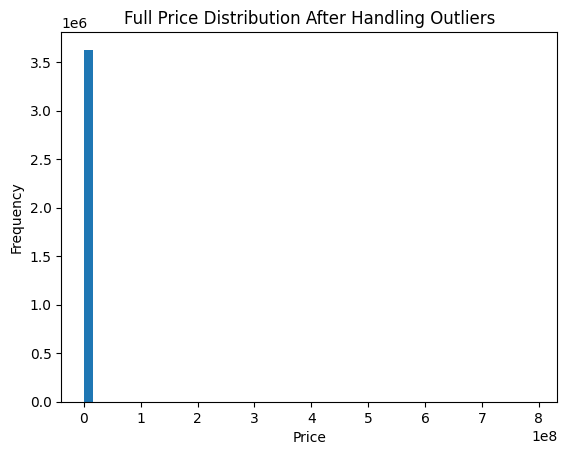

In [8]:
plt.figure()
plt.hist(df['price'], bins=50)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Full Price Distribution After Handling Outliers')
plt.show()

In [9]:
df = df[df['ppd_category_type'] == 'A']

In [10]:
display(df['price'].describe())

upper = df['price'].quantile(0.995)
lower = df['price'].quantile(0.001)

,price
count,3.042101e+06
mean,3.676222e+05
std,4.123564e+05
min,1.000000e+00
25%,1.930000e+05
50%,2.900000e+05
75%,4.300000e+05
max,1.345000e+08


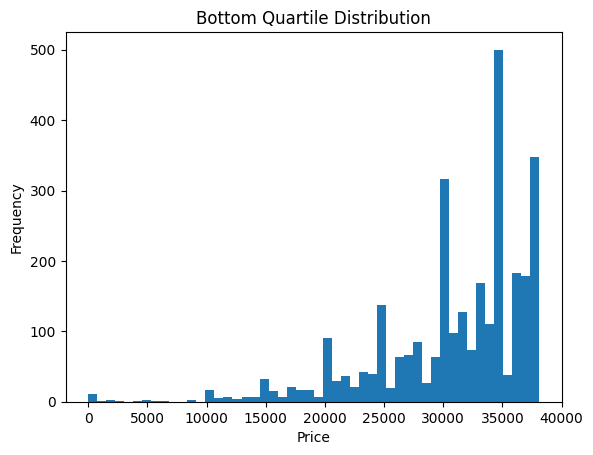

In [11]:
plt.figure()
plt.hist(df['price'][df['price'] <= lower], bins=50)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Bottom Quartile Distribution')
plt.show()

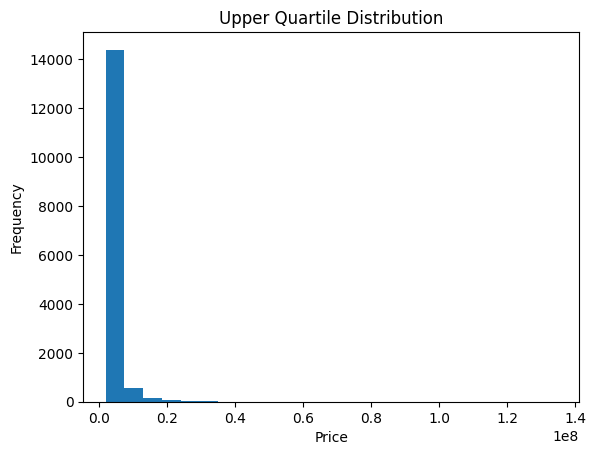

In [12]:
plt.figure()
plt.hist(df['price'][df['price'] >= upper], bins=24)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Upper Quartile Distribution')
plt.show()

In [13]:
df = df[df['price'] >= 10000]

In [14]:
df = df[df['price']<=upper]

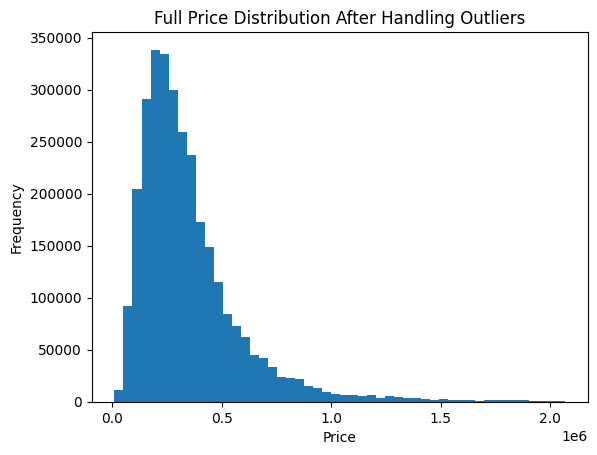

In [15]:
plt.figure()
plt.hist(df['price'], bins=50)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Full Price Distribution After Handling Outliers')
plt.show()

In [16]:
df['price'].max()

2070000

## DATA SAMPLING

In [17]:
df_sampled = df[
    (df['date_of_transfer'] >= '2025-06-01') &
    (df['date_of_transfer'] <= '2026-1-31')
]
df_sampled

,price,date_of_transfer,postcode,property_type,old_new,duration,street,town_city,district,county,ppd_category_type,year,district_clean,Area (sq km),Estimated Population mid-2024,2024 people per sq. km,area_type
2856020,795000,2025-10-24,SK10 5XF,D,N,F,CHAPEL BROW,MACCLESFIELD,CHESHIRE EAST,CHESHIRE EAST,A,2025,CHESHIRE EAST,1166,421298,361,Urban
2856021,141000,2025-11-21,SK11 7AF,T,N,F,JODRELL STREET,MACCLESFIELD,CHESHIRE EAST,CHESHIRE EAST,A,2025,CHESHIRE EAST,1166,421298,361,Urban
2856022,184000,2025-11-27,CH4 7NP,T,N,F,BARONY WAY,CHESTER,CHESHIRE WEST AND CHESTER,CHESHIRE WEST AND CHESTER,A,2025,CHESHIRE WEST AND CHESTER,920,371652,404,Urban
2856023,263000,2025-06-20,WA8 7NN,S,N,F,LYNTON CRESCENT,WIDNES,HALTON,HALTON,A,2025,HALTON,79,131543,1663,Urban
2856024,630000,2025-07-09,CH3 5QB,D,N,F,WHITCHURCH ROAD,CHESTER,CHESHIRE WEST AND CHESTER,CHESHIRE WEST AND CHESTER,A,2025,CHESHIRE WEST AND CHESTER,920,371652,404,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3629275,875000,2026-01-15,RG41 4XJ,D,N,F,JAPONICA CLOSE,WOKINGHAM,WOKINGHAM,WOKINGHAM,A,2026,WOKINGHAM,179,187200,1046,Urban
3629276,370000,2026-01-14,RG20 6QQ,T,N,F,MEADOW CLOSE,NEWBURY,WEST BERKSHIRE,WEST BERKSHIRE,A,2026,WEST BERKSHIRE,704,165112,234,Rural
3629277,700000,2026-01-15,SL3 9NQ,S,N,F,FAIRFIELD AVENUE,SLOUGH,WINDSOR AND MAIDENHEAD,WINDSOR AND MAIDENHEAD,A,2026,WINDSOR AND MAIDENHEAD,196,158943,809,Urban
3629278,283000,2026-01-16,GU47 0ZB,T,N,F,STUBBS FOLLY,SANDHURST,BRACKNELL FOREST,BRACKNELL FOREST,A,2026,BRACKNELL FOREST,109,130806,1196,Urban


## DISTRIBUTION CHECKING

In [18]:
df_district = df_sampled['district'].value_counts()
display(df_district)

df_district.describe()

,count
district,
NORTH YORKSHIRE,4969
LEEDS,4922
SOMERSET,4293
BIRMINGHAM,4278
CORNWALL,4115
...,...
RUTLAND,312
OADBY AND WIGSTON,290
MERTHYR TYDFIL,261


,count
count,318.000000
mean,1143.474843
std,742.109168
min,5.000000
25%,717.250000
50%,948.500000
75%,1292.000000
max,4969.000000


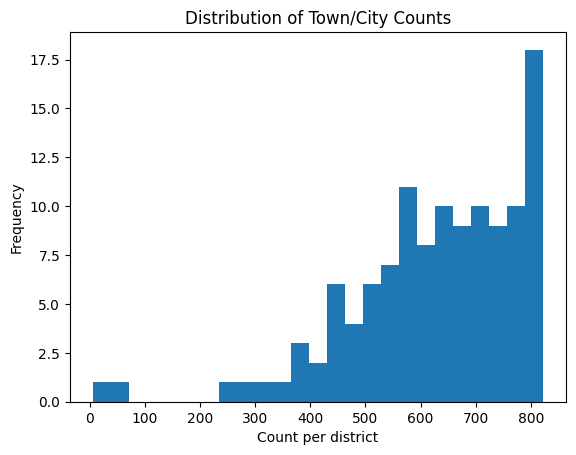

In [19]:
plt.figure()
plt.hist(df_district[df_district < 826], bins=25)
plt.xlabel('Count per district')
plt.ylabel('Frequency')
plt.title('Distribution of Town/City Counts')
plt.show()

In [20]:
df_tc = df_sampled['town_city'].value_counts()
display(df_tc)
df_tc.describe()

,count
town_city,
LONDON,20411
BRISTOL,6045
MANCHESTER,5617
NOTTINGHAM,4891
BIRMINGHAM,4332
...,...
MONTACUTE,2
MINDRUM,1
DULAS,1


,count
count,1144.000000
mean,317.854021
std,782.597679
min,1.000000
25%,59.750000
50%,152.000000
75%,319.250000
max,20411.000000


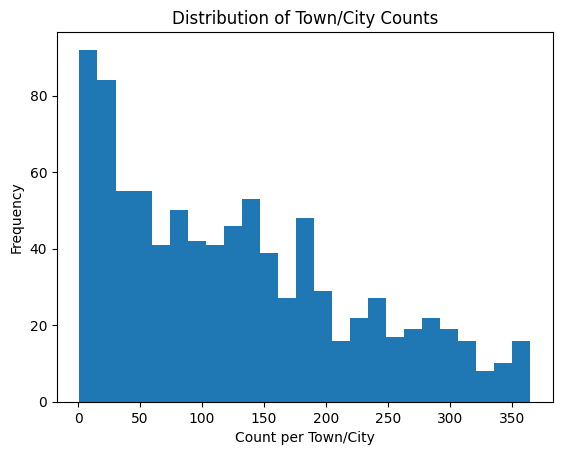

In [21]:
plt.figure()
plt.hist(df_tc[df_tc < 367], bins=25)
plt.xlabel('Count per Town/City')
plt.ylabel('Frequency')
plt.title('Distribution of Town/City Counts')
plt.show()

In [22]:
df_county = df_sampled['county'].value_counts()
display(df_county)
df_county.describe()

,count
county,
GREATER LONDON,35028
GREATER MANCHESTER,15986
WEST YORKSHIRE,14837
WEST MIDLANDS,12275
KENT,10682
...,...
ISLE OF ANGLESEY,391
BLAENAU GWENT,364
RUTLAND,312


,count
count,113.000000
mean,3217.920354
std,4307.866805
min,5.000000
25%,1021.000000
50%,1416.000000
75%,4152.000000
max,35028.000000


In [23]:
df_sampled['county'].replace('ISLES OF SCILLY', 'CORNWALL', inplace=True)
df_county = df_sampled['county'].value_counts()
display(df_county)
df_county.describe()

,count
county,
GREATER LONDON,35028
GREATER MANCHESTER,15986
WEST YORKSHIRE,14837
WEST MIDLANDS,12275
KENT,10682
...,...
SLOUGH,423
ISLE OF ANGLESEY,391
BLAENAU GWENT,364


,count
count,112.000000
mean,3246.651786
std,4316.381870
min,261.000000
25%,1021.750000
50%,1438.000000
75%,4187.250000
max,35028.000000


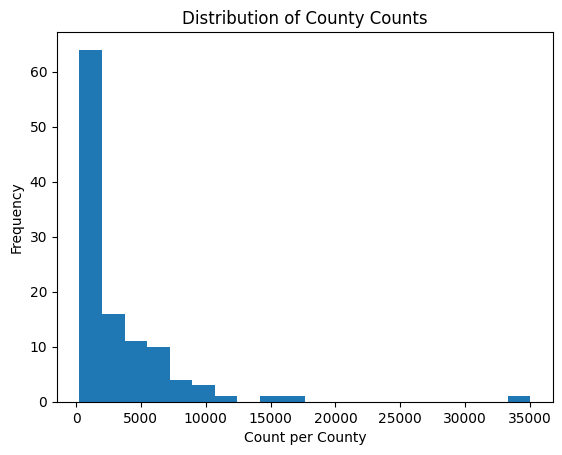

In [24]:
plt.figure()
plt.hist(df_county, bins=20)
plt.xlabel('Count per County')
plt.ylabel('Frequency')
plt.title('Distribution of County Counts')
plt.show()

In [25]:
df_sampled['old_new'].value_counts()

,count
old_new,
N,360279
Y,3346


In [26]:
df_sampled['duration'].value_counts()

,count
duration,
F,289979
L,73646


In [27]:
df_sampled['property_type'].value_counts()

,count
property_type,
S,109964
T,105986
D,90441
F,57234


In [28]:
df.isna().sum()

,0
price,0
date_of_transfer,0
postcode,524
property_type,0
old_new,0
duration,0
street,41569
town_city,0
district,0
county,0


In [29]:
df_price = df_sampled['price']

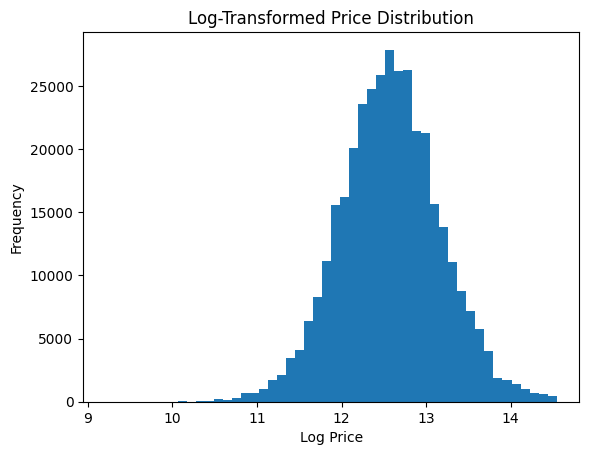

In [30]:
plt.figure()
plt.hist(np.log1p(df_price), bins=50)
plt.xlabel('Log Price')
plt.ylabel('Frequency')
plt.title('Log-Transformed Price Distribution')
plt.show()

In [31]:
df_price.describe()

,price
count,3.636250e+05
mean,3.476698e+05
std,2.318235e+05
min,1.000000e+04
25%,1.957000e+05
50%,2.900000e+05
75%,4.250000e+05
max,2.070000e+06


In [32]:
df_price.min()

10000

## SPLITTING

In [33]:
train_mask = (df["date_of_transfer"] >= "2025-06-01") & (df["date_of_transfer"] <= "2025-11-30")
# valid_mask = (df["date_of_transfer"] >= "2025-12-01") & (df["date_of_transfer"] <= "2025-12-31")
test_mask  = (df["date_of_transfer"] >= "2025-12-01") & (df["date_of_transfer"] <= "2026-01-31")

train_df = df[train_mask].copy()
# valid_df = df[valid_mask].copy()
test_df  = df[test_mask].copy()

In [34]:
total_data = len(df_sampled)

print(f'{len(train_df)} ({len(train_df)/total_data*100} %)')
# print(f'{len(valid_df)} ({len(valid_df)/total_data*100} %)')
print(f'{len(test_df)} ({len(test_df)/total_data*100} %)')

305785 (84.09350292196632 %)
57840 (15.906497078033688 %)


## CLEANING

In [35]:
train_df.columns

Index(['price', 'date_of_transfer', 'postcode', 'property_type', 'old_new',
       'duration', 'street', 'town_city', 'district', 'county',
       'ppd_category_type', 'year', 'district_clean', 'Area (sq km)',
       'Estimated Population mid-2024', '2024 people per sq. km', 'area_type'],
      dtype='object')

In [36]:
display(train_df.isna().sum())
display(test_df.isna().sum())

,0
price,0
date_of_transfer,0
postcode,84
property_type,0
old_new,0
duration,0
street,4109
town_city,0
district,0
county,0


,0
price,0
date_of_transfer,0
postcode,19
property_type,0
old_new,0
duration,0
street,846
town_city,0
district,0
county,0


In [37]:
def clean_df(d):
    d = d.copy()
    d["date_of_transfer"] = pd.to_datetime(d["date_of_transfer"])
    d = d.drop(columns=["postcode", "street", "ppd_category_type", "district_clean"]) #Postcode and Street remove due to too many missing value and too high cardinality, ppd_category_type is due to only one type is in this dataset
    d["month"] = d["date_of_transfer"].dt.month
    d = d.drop(columns=["date_of_transfer", "year"])

    return d

train_df = clean_df(train_df)
# valid_df = clean_df(valid_df)
test_df  = clean_df(test_df)

In [38]:
print(train_df.isna().sum().sum())
print(train_df.isna().sum().sum())
print(train_df.isna().sum().sum())

0
0
0


In [39]:
train_df.head()

,price,property_type,old_new,duration,town_city,district,county,Area (sq km),Estimated Population mid-2024,2024 people per sq. km,area_type,month
2856020,795000,D,N,F,MACCLESFIELD,CHESHIRE EAST,CHESHIRE EAST,1166,421298,361,Urban,10
2856021,141000,T,N,F,MACCLESFIELD,CHESHIRE EAST,CHESHIRE EAST,1166,421298,361,Urban,11
2856022,184000,T,N,F,CHESTER,CHESHIRE WEST AND CHESTER,CHESHIRE WEST AND CHESTER,920,371652,404,Urban,11
2856023,263000,S,N,F,WIDNES,HALTON,HALTON,79,131543,1663,Urban,6
2856024,630000,D,N,F,CHESTER,CHESHIRE WEST AND CHESTER,CHESHIRE WEST AND CHESTER,920,371652,404,Urban,7


In [40]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 305785 entries, 2856020 to 3613272
Data columns (total 12 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   price                          305785 non-null  int64 
 1   property_type                  305785 non-null  object
 2   old_new                        305785 non-null  object
 3   duration                       305785 non-null  object
 4   town_city                      305785 non-null  object
 5   district                       305785 non-null  object
 6   county                         305785 non-null  object
 7   Area (sq km)                   305785 non-null  int64 
 8   Estimated Population mid-2024  305785 non-null  int64 
 9   2024 people per sq. km         305785 non-null  int64 
 10  area_type                      305785 non-null  object
 11  month                          305785 non-null  int32 
dtypes: int32(1), int64(4), object(7)
memory us

In [41]:
target = "price"

X_train = train_df.drop(columns=[target])
y_train = train_df[target]

# X_valid = valid_df.drop(columns=[target])
# y_valid = valid_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

In [42]:
display(y_train)
display(y_test)

,price
2856020,795000
2856021,141000
2856022,184000
2856023,263000
2856024,630000
...,...
3613263,332500
3613267,367500
3613270,395000
3613271,125000


,price
2856026,305000
2856029,242000
2856031,927500
2856033,194000
2856035,232500
...,...
3629275,875000
3629276,370000
3629277,700000
3629278,283000


### LOG TRANSFORM

In [43]:
# Apply log transform only to the training set
y_train_log = np.log1p(y_train)
# y_test_log  = np.log1p(y_test)

## ENCODING

### LOW CARDINALITY COLUMN ENCODING

In [44]:
binary_cols = ["old_new", "duration", "area_type"]

maps = {
    "old_new": {"N": 0, "Y": 1},
    "duration": {"L": 0, "F": 1},
    "area_type": {"Urban": 1, "Rural": 0}

}

for col in binary_cols:
    X_train[col] = X_train[col].map(maps[col])
    # X_valid[col] = X_valid[col].map(maps[col])
    X_test[col]  = X_test[col].map(maps[col])

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_ohe = ohe.fit_transform(X_train[['property_type']])
# X_valid_ohe = ohe.transform(X_valid[['property_type']])
X_test_ohe  = ohe.transform(X_test[['property_type']])

In [45]:
ohe_cols = ohe.get_feature_names_out(['property_type']).tolist()

ohe_train_df = pd.DataFrame(X_train_ohe, columns=ohe_cols, index=X_train.index)
# ohe_valid_df = pd.DataFrame(X_valid_ohe, columns=ohe_cols, index=X_valid.index)
ohe_test_df  = pd.DataFrame(X_test_ohe,  columns=ohe_cols, index=X_test.index)


In [46]:
ohe_train_df

,property_type_D,property_type_F,property_type_S,property_type_T
2856020,1.0,0.0,0.0,0.0
2856021,0.0,0.0,0.0,1.0
2856022,0.0,0.0,0.0,1.0
2856023,0.0,0.0,1.0,0.0
2856024,1.0,0.0,0.0,0.0
...,...,...,...,...
3613263,1.0,0.0,0.0,0.0
3613267,0.0,0.0,1.0,0.0
3613270,0.0,0.0,1.0,0.0
3613271,0.0,1.0,0.0,0.0


In [47]:
X_train = pd.concat([X_train.drop(columns=['property_type']), ohe_train_df], axis=1)
# X_valid = pd.concat([X_valid.drop(columns=['property_type']), ohe_valid_df], axis=1)
X_test  = pd.concat([X_test.drop(columns=['property_type']),  ohe_test_df],  axis=1)

### HIGH CARDINALITY ENCODING

In [48]:
train_df["price_log"] = np.log1p(train_df["price"]) # Using train_df to prevent data leaking

te = TargetEncoder(
    cols=["town_city", "district", "county"],
)

te.fit(
    train_df[["town_city", "district", "county"]],
    train_df["price_log"]
)

X_train_te = te.transform(X_train[["town_city", "district", "county"]])
X_test_te  = te.transform(X_test[["town_city", "district", "county"]])

# Rename columns (optional, cleaner)
X_train_te.columns = ["town_city_te", "district_te", "county_te"]
X_test_te.columns  = ["town_city_te", "district_te", "county_te"]

X_train = pd.concat([X_train, X_train_te], axis=1)
X_test  = pd.concat([X_test, X_test_te], axis=1)

X_train = X_train.drop(columns=["town_city", "district", "county"])
X_test  = X_test.drop(columns=["town_city", "district", "county"])

### CYCLICAL ENCODING

In [49]:
for df in [X_train,
          #  X_valid,
           X_test]:
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# drop original
X_train = X_train.drop(columns=["month"])
# X_valid = X_valid.drop(columns=["month"])
X_test  = X_test.drop(columns=["month"])

In [50]:
X_train

,old_new,duration,Area (sq km),Estimated Population mid-2024,2024 people per sq. km,area_type,property_type_D,property_type_F,property_type_S,property_type_T,town_city_te,district_te,county_te,month_sin,month_cos
2856020,0,1,1166,421298,361,1,1.0,0.0,0.0,0.0,12.631372,12.613582,12.613582,-8.660254e-01,5.000000e-01
2856021,0,1,1166,421298,361,1,0.0,0.0,0.0,1.0,12.631372,12.613582,12.613582,-5.000000e-01,8.660254e-01
2856022,0,1,920,371652,404,1,0.0,0.0,0.0,1.0,12.526525,12.483376,12.483376,-5.000000e-01,8.660254e-01
2856023,0,1,79,131543,1663,1,0.0,0.0,1.0,0.0,12.168847,12.156665,12.156665,1.224647e-16,-1.000000e+00
2856024,0,1,920,371652,404,1,1.0,0.0,0.0,0.0,12.526525,12.483376,12.483376,-5.000000e-01,-8.660254e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3613263,0,1,663,138017,208,0,1.0,0.0,0.0,0.0,12.643274,12.708921,12.586363,-1.000000e+00,-1.836970e-16
3613267,0,1,33,106671,3199,1,0.0,0.0,1.0,0.0,12.553285,12.440386,12.586363,-8.660254e-01,-5.000000e-01
3613270,0,1,54,87847,1619,1,0.0,0.0,1.0,0.0,12.457635,12.439248,12.586363,-5.000000e-01,-8.660254e-01
3613271,0,0,33,106671,3199,1,0.0,1.0,0.0,0.0,12.553285,12.440386,12.586363,-5.000000e-01,8.660254e-01


In [51]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 305785 entries, 2856020 to 3613272
Data columns (total 15 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   old_new                        305785 non-null  int64  
 1   duration                       305785 non-null  int64  
 2   Area (sq km)                   305785 non-null  int64  
 3   Estimated Population mid-2024  305785 non-null  int64  
 4   2024 people per sq. km         305785 non-null  int64  
 5   area_type                      305785 non-null  int64  
 6   property_type_D                305785 non-null  float64
 7   property_type_F                305785 non-null  float64
 8   property_type_S                305785 non-null  float64
 9   property_type_T                305785 non-null  float64
 10  town_city_te                   305785 non-null  float64
 11  district_te                    305785 non-null  float64
 12  county_te                   

In [52]:
print(X_train)

         old_new  duration  Area (sq km)  Estimated Population mid-2024  \
2856020        0         1          1166                         421298   
2856021        0         1          1166                         421298   
2856022        0         1           920                         371652   
2856023        0         1            79                         131543   
2856024        0         1           920                         371652   
...          ...       ...           ...                            ...   
3613263        0         1           663                         138017   
3613267        0         1            33                         106671   
3613270        0         1            54                          87847   
3613271        0         0            33                         106671   
3613272        0         1           577                          83227   

         2024 people per sq. km  area_type  property_type_D  property_type_F  \
2856020            

In [53]:
y_test

,price
2856026,305000
2856029,242000
2856031,927500
2856033,194000
2856035,232500
...,...
3629275,875000
3629276,370000
3629277,700000
3629278,283000


In [54]:
display(y_train.describe())
# display(y_valid.describe())
display(y_test.describe())

,price
count,3.057850e+05
mean,3.489193e+05
std,2.348531e+05
min,1.000000e+04
25%,1.950000e+05
50%,2.900000e+05
75%,4.250000e+05
max,2.070000e+06


,price
count,5.784000e+04
mean,3.410641e+05
std,2.149805e+05
min,1.500000e+04
25%,1.980000e+05
50%,2.900000e+05
75%,4.220000e+05
max,2.060000e+06


## FEATURE SELECTION

In [55]:
X_train.columns

Index(['old_new', 'duration', 'Area (sq km)', 'Estimated Population mid-2024',
       '2024 people per sq. km', 'area_type', 'property_type_D',
       'property_type_F', 'property_type_S', 'property_type_T', 'town_city_te',
       'district_te', 'county_te', 'month_sin', 'month_cos'],
      dtype='object')

### COREALTION CHECKING

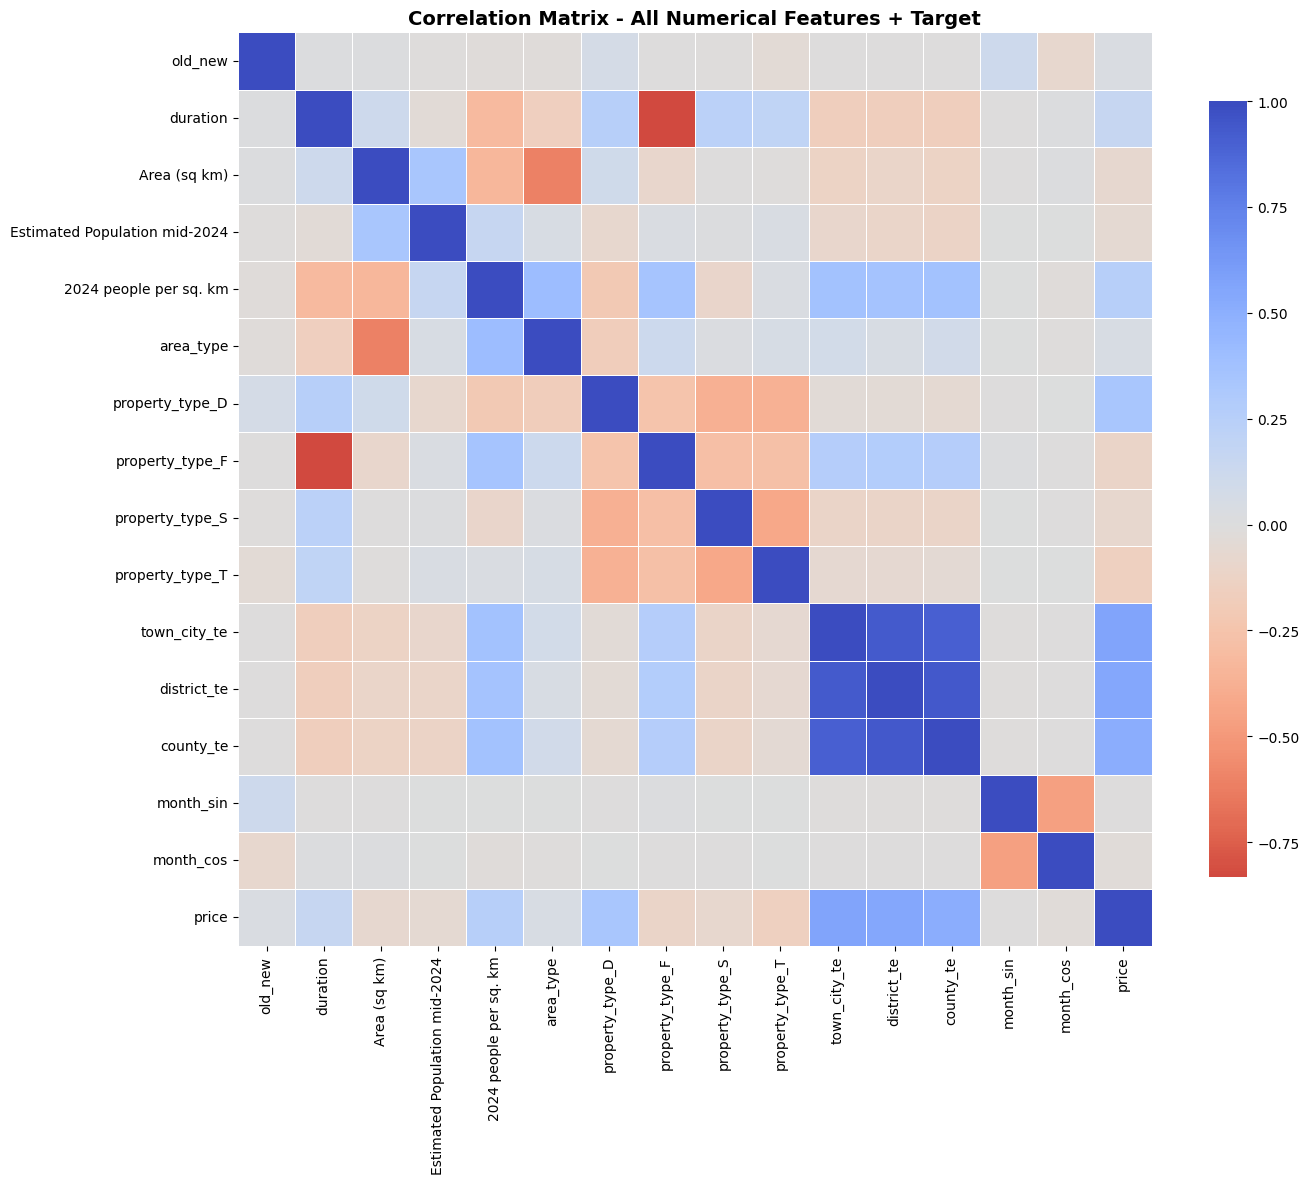


📊 Top 10 Features Correlated with Price:
price                            1.000000
town_city_te                     0.566755
district_te                      0.553815
county_te                        0.511130
property_type_D                  0.340341
2024 people per sq. km           0.248596
duration                         0.156899
area_type                        0.047630
old_new                          0.027142
month_sin                       -0.008751
month_cos                       -0.028168
Estimated Population mid-2024   -0.054748
Area (sq km)                    -0.071266
property_type_S                 -0.077139
property_type_F                 -0.116145
property_type_T                 -0.152379
Name: price, dtype: float64


In [56]:
from sklearn.ensemble import RandomForestRegressor

# Train baseline RandomForest model for importance analysis
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Add target to training set for correlation
X_train_with_target = X_train.copy()
X_train_with_target['price'] = y_train.values

# Correlation matrix
correlation_matrix = X_train_with_target.corr()

# Create heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, cmap='coolwarm_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot=False)  # annot=True if you want to see all values
plt.title('Correlation Matrix - All Numerical Features + Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Show top correlations with price
price_corr = correlation_matrix['price'].sort_values(ascending=False)
print("\n📊 Top 10 Features Correlated with Price:")
print(price_corr)

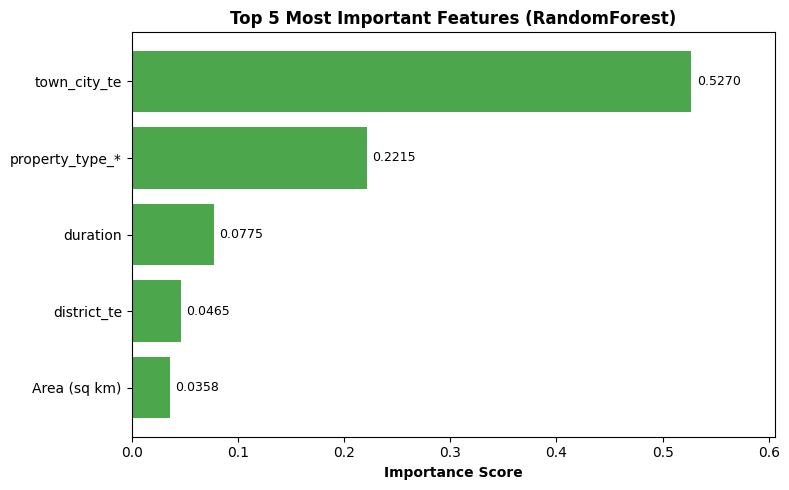

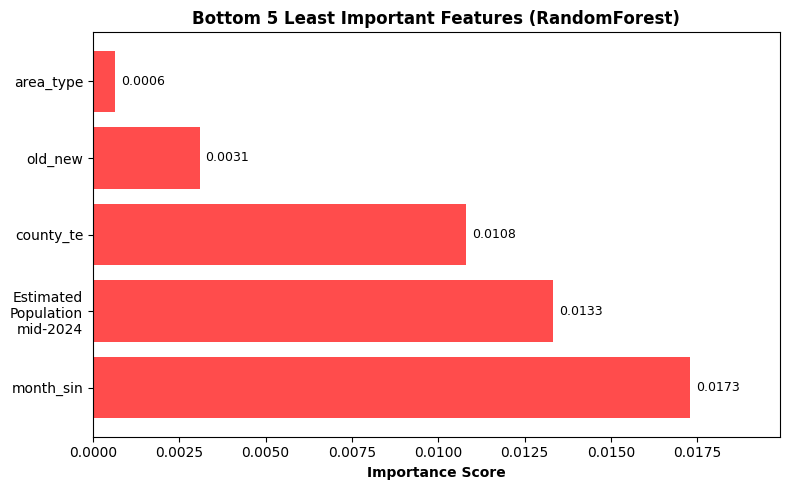


📊 Grouped Feature Importance (RandomForest):
town_city_te                     0.526966
property_type_*                  0.221488
duration                         0.077512
district_te                      0.046540
Area (sq km)                     0.035761
month_cos                        0.027799
2024 people per sq. km           0.018772
month_sin                        0.017297
Estimated Population mid-2024    0.013330
county_te                        0.010807
old_new                          0.003091
area_type                        0.000636
dtype: float64


In [66]:
rf_importance = pd.Series(model.feature_importances_, index=X_train.columns)
rf_importance = rf_importance.sort_values(ascending=False)

def group_encoded_features(importance_series):
    """Group one-hot encoded and target encoded features together"""
    grouped = {}
    other_features = {}

    for feature, score in importance_series.items():
        if feature.startswith('property_type_'):
            if 'property_type_*' not in grouped:
                grouped['property_type_*'] = 0
            grouped['property_type_*'] += score
        elif feature.endswith('_te'):
            if feature not in grouped:
                grouped[feature] = 0
            grouped[feature] += score
        else:
            other_features[feature] = score

    final_importance = {**grouped, **other_features}
    return pd.Series(final_importance).sort_values(ascending=False)

rf_importance_grouped = group_encoded_features(rf_importance)

# --- Plot 1: Top 5 ---
fig1, ax1 = plt.subplots(figsize=(8, 5))
top_5 = rf_importance_grouped.head(5)
ax1.barh(range(len(top_5)), top_5.values, color='green', alpha=0.7)
ax1.set_yticks(range(len(top_5)))
ax1.set_yticklabels(top_5.index)
ax1.set_xlabel('Importance Score', fontweight='bold')
ax1.set_title('Top 5 Most Important Features (RandomForest)', fontweight='bold', fontsize=12)
ax1.invert_yaxis()
ax1.set_xlim(0, top_5.values.max() * 1.15)  # add 15% padding on the right
for i, v in enumerate(top_5.values):
    ax1.text(v + top_5.values.max() * 0.01, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


# --- Plot 2: Bottom 5 ---
fig2, ax2 = plt.subplots(figsize=(8, 5))
bottom_5 = rf_importance_grouped.tail(5)
bottom_5 = bottom_5[::-1]
ax2.barh(range(len(bottom_5)), bottom_5.values, color='red', alpha=0.7)
ax2.set_yticks(range(len(bottom_5)))
ax2.set_yticklabels([label.replace(' ', '\n') if len(label) > 15 else label
                     for label in bottom_5.index])  # wrap long labels
ax2.set_xlabel('Importance Score', fontweight='bold')
ax2.set_title('Bottom 5 Least Important Features (RandomForest)', fontweight='bold', fontsize=12)
ax2.invert_yaxis()
ax2.set_xlim(0, bottom_5.values.max() * 1.15)
for i, v in enumerate(bottom_5.values):
    ax2.text(v + bottom_5.values.max() * 0.01, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\n📊 Grouped Feature Importance (RandomForest):")
print(rf_importance_grouped)

### FEATURE IMPORTANCE

In [61]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

# Feature importance
importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(15))

town_city_te                     0.526961
property_type_D                  0.200377
duration                         0.078105
district_te                      0.046537
Area (sq km)                     0.035804
month_cos                        0.027502
2024 people per sq. km           0.018356
month_sin                        0.017315
property_type_S                  0.015970
Estimated Population mid-2024    0.013367
county_te                        0.010906
old_new                          0.003156
property_type_F                  0.002676
property_type_T                  0.002338
area_type                        0.000631
dtype: float64


In [67]:
display(X_train)
display(X_test)

,old_new,duration,Area (sq km),Estimated Population mid-2024,2024 people per sq. km,area_type,property_type_D,property_type_F,property_type_S,property_type_T,town_city_te,district_te,county_te,month_sin,month_cos
2856020,0,1,1166,421298,361,1,1.0,0.0,0.0,0.0,12.631372,12.613582,12.613582,-8.660254e-01,5.000000e-01
2856021,0,1,1166,421298,361,1,0.0,0.0,0.0,1.0,12.631372,12.613582,12.613582,-5.000000e-01,8.660254e-01
2856022,0,1,920,371652,404,1,0.0,0.0,0.0,1.0,12.526525,12.483376,12.483376,-5.000000e-01,8.660254e-01
2856023,0,1,79,131543,1663,1,0.0,0.0,1.0,0.0,12.168847,12.156665,12.156665,1.224647e-16,-1.000000e+00
2856024,0,1,920,371652,404,1,1.0,0.0,0.0,0.0,12.526525,12.483376,12.483376,-5.000000e-01,-8.660254e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3613263,0,1,663,138017,208,0,1.0,0.0,0.0,0.0,12.643274,12.708921,12.586363,-1.000000e+00,-1.836970e-16
3613267,0,1,33,106671,3199,1,0.0,0.0,1.0,0.0,12.553285,12.440386,12.586363,-8.660254e-01,-5.000000e-01
3613270,0,1,54,87847,1619,1,0.0,0.0,1.0,0.0,12.457635,12.439248,12.586363,-5.000000e-01,-8.660254e-01
3613271,0,0,33,106671,3199,1,0.0,1.0,0.0,0.0,12.553285,12.440386,12.586363,-5.000000e-01,8.660254e-01


,old_new,duration,Area (sq km),Estimated Population mid-2024,2024 people per sq. km,area_type,property_type_D,property_type_F,property_type_S,property_type_T,town_city_te,district_te,county_te,month_sin,month_cos
2856026,0,1,920,371652,404,1,0.0,0.0,1.0,0.0,12.526525,12.483376,12.483376,-2.449294e-16,1.000000
2856029,0,1,920,371652,404,1,0.0,0.0,1.0,0.0,12.247309,12.483376,12.483376,-2.449294e-16,1.000000
2856031,0,1,1166,421298,361,1,1.0,0.0,0.0,0.0,12.636827,12.613582,12.613582,-2.449294e-16,1.000000
2856033,0,1,1166,421298,361,1,0.0,0.0,1.0,0.0,12.357480,12.613582,12.613582,-2.449294e-16,1.000000
2856035,0,1,920,371652,404,1,0.0,0.0,1.0,0.0,12.219231,12.483376,12.483376,-2.449294e-16,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3629275,0,1,179,187200,1046,1,1.0,0.0,0.0,0.0,13.114440,13.074645,13.074645,5.000000e-01,0.866025
3629276,0,1,704,165112,234,0,0.0,0.0,0.0,1.0,12.829983,12.895507,12.895507,5.000000e-01,0.866025
3629277,0,1,196,158943,809,1,0.0,0.0,1.0,0.0,12.912676,13.198454,13.198454,5.000000e-01,0.866025
3629278,0,1,109,130806,1196,1,0.0,0.0,0.0,1.0,12.999777,12.931995,12.931995,5.000000e-01,0.866025


### FEATURE SELECTION

In [68]:
features_drop = ['area_type', 'county_te', 'old_new', 'Estimated Population mid-2024']
X_train = X_train.drop(columns=features_drop)
X_test  = X_test.drop(columns=features_drop)

# MODELING

In [69]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

## Baseline Hyperparameter

In [70]:
# Linear Regression Model
lr = LinearRegression()

# Random Forest Model
rf = RandomForestRegressor(
    random_state=42
)

# XGBoost Model
xgb = XGBRegressor(
    random_state=42
)

# LightGBM Model
lgbm = LGBMRegressor(
    random_state=42
)

# Gradient Boosting Model
gb = GradientBoostingRegressor(
    random_state=42
)

In [71]:
models = {
    'Linear Regression': lr,
    'Random Forest Regressor': rf,
    'XGBoost Regressor': xgb,
    'LightGBM Regressor': lgbm,
    'Gradient Boosting Regressor': gb,
}


In [72]:
X_train.isna().sum()

,0
duration,0
Area (sq km),0
2024 people per sq. km,0
property_type_D,0
property_type_F,0
property_type_S,0
property_type_T,0
town_city_te,0
district_te,0
month_sin,0


In [73]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 305785 entries, 2856020 to 3613272
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   duration                305785 non-null  int64  
 1   Area (sq km)            305785 non-null  int64  
 2   2024 people per sq. km  305785 non-null  int64  
 3   property_type_D         305785 non-null  float64
 4   property_type_F         305785 non-null  float64
 5   property_type_S         305785 non-null  float64
 6   property_type_T         305785 non-null  float64
 7   town_city_te            305785 non-null  float64
 8   district_te             305785 non-null  float64
 9   month_sin               305785 non-null  float64
 10  month_cos               305785 non-null  float64
dtypes: float64(8), int64(3)
memory usage: 28.0 MB


In [74]:
import numpy as np
import pandas as pd
import os
import pickle
from sklearn.model_selection import KFold, cross_validate

kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []
os.makedirs("models", exist_ok=True)

for name, model in models.items():
    # Cross-validation
    cv_scores = cross_validate(
        model,
        X_train,
        y_train_log,
        cv=kf,
        scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2'],
    )

    # Store results
    results.append({
        'Model': name,
        'Root Mean Squared Error': -cv_scores['test_neg_root_mean_squared_error'].mean(),
        'Mean Absolute Error': -cv_scores['test_neg_mean_absolute_error'].mean(),
        'R2 Score': cv_scores['test_r2'].mean()
    })

    # Train on FULL training data
    model.fit(X_train, y_train_log)

    # ✅ Save model as .pkl
    with open(f"models/{name}.pkl", "wb") as f:
        pickle.dump(model, f)

# Results dataframe
df_results = pd.DataFrame(results)\
    .sort_values(by='R2 Score', ascending=False)\
    .reset_index(drop=True)

df_results

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022292 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1006
[LightGBM] [Info] Number of data points in the train set: 244628, number of used features: 11
[LightGBM] [Info] Start training from score 12.582529
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006765 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1008
[LightGBM] [Info] Number of data points in the train set: 244628, number of used features: 11
[LightGBM] [Info] Start training from score 12.581857
[LightGBM] [Warning] Fou

,Model,Root Mean Squared Error,Mean Absolute Error,R2 Score
0,XGBoost Regressor,0.330403,0.245154,0.694653
1,LightGBM Regressor,0.333458,0.247840,0.688980
2,Gradient Boosting Regressor,0.339620,0.253034,0.677380
3,Random Forest Regressor,0.342401,0.254930,0.672075
4,Linear Regression,0.347494,0.259321,0.662246


# HYPERPARAMETER TUNING

In [75]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

In [76]:
param_xgb_distribution = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": uniform(loc=0.5, scale=0.5),
    "colsample_bytree": uniform(loc=0.5, scale=0.5),
    "min_child_weight": range(1, 8, 2),
    "max_depth": [3, 4, 5, 6, 8, 10, 12, 15],
    "alpha": [0, 0.01, 0.05, 1, 2, 5],
    "lambda": [0, 0.01, 0.05, 1, 2, 5]
}

param_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_xgb_distribution,
    n_iter=5,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    verbose=2
)

param_search_xgb.fit(X_train, y_train,
                    #  eval_set=[(X_val, y_val)],
                    #  callbacks=[early_stopping(20)]
)

xgb_tuned = param_search_xgb.best_estimator_

display(param_search_xgb.best_params_)



Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END alpha=1, colsample_bytree=0.9753571532049581, lambda=0.05, learning_rate=0.2, max_depth=8, min_child_weight=1, n_estimators=100, subsample=0.7229163764267956; total time=   2.5s
[CV] END alpha=1, colsample_bytree=0.9753571532049581, lambda=0.05, learning_rate=0.2, max_depth=8, min_child_weight=1, n_estimators=100, subsample=0.7229163764267956; total time=   4.7s
[CV] END alpha=1, colsample_bytree=0.9753571532049581, lambda=0.05, learning_rate=0.2, max_depth=8, min_child_weight=1, n_estimators=100, subsample=0.7229163764267956; total time=   3.7s
[CV] END alpha=1, colsample_bytree=0.9753571532049581, lambda=0.05, learning_rate=0.2, max_depth=8, min_child_weight=1, n_estimators=100, subsample=0.7229163764267956; total time=   2.5s
[CV] END alpha=1, colsample_bytree=0.9753571532049581, lambda=0.05, learning_rate=0.2, max_depth=8, min_child_weight=1, n_estimators=100, subsample=0.7229163764267956; total time=   2.6s
[CV] 

{'alpha': 1,
 'colsample_bytree': np.float64(0.9753571532049581),
 'lambda': 0.05,
 'learning_rate': 0.2,
 'max_depth': 8,
 'min_child_weight': 1,
 'n_estimators': 100,
 'subsample': np.float64(0.7229163764267956)}

In [77]:
## Turn of the quote if wanna try eary stopping (must be providing validation set)

# from lightgbm import early_stopping

# lgbm = LGBMRegressor(n_estimators=10000, n_jobs=-1, random_state=42)

param_lgbm_distribution = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": uniform(loc=0.5, scale=0.5),
    "colsample_bytree": uniform(loc=0.5, scale=0.5),
    "min_child_samples": randint(5, 300),
    "max_depth": [3, 4, 5, 6, 8, 10, 12, 15],
    "alpha": [0, 0.01, 0.05, 1, 2, 5],
    "lambda": [0, 0.01, 0.05, 1, 2, 5]
}

param_search_lgbm = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_lgbm_distribution,
    n_iter=5,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

param_search_lgbm.fit(X_train, y_train,
                      # eval_set=[(X_val, y_val)],
                      # callbacks=[early_stopping(20)]
)

lgbm_tuned = param_search_lgbm.best_estimator_

display(param_search_lgbm.best_params_)


Fitting 5 folds for each of 5 candidates, totalling 25 fits
[LightGBM] [Warning] lambda_l2 is set with lambda=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] lambda_l2 is set with lambda=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004245 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1006
[LightGBM] [Info] Number of data points in the train set: 305785, number of used features: 11
[LightGBM] [Info] Start training from score 348919.333198


{'alpha': 0.01,
 'colsample_bytree': np.float64(0.5233328316068078),
 'lambda': 1,
 'learning_rate': 0.2,
 'max_depth': 12,
 'min_child_samples': 194,
 'n_estimators': 200,
 'subsample': np.float64(0.8925879806965068)}

# FINAL EVALUATION

In [78]:
import os
import pickle
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

tuned_model = {
    'XGBoost Regressor': xgb_tuned,
    'LightGBM Regressor': lgbm_tuned
}

tuned_result = []
os.makedirs("models", exist_ok=True)

for name, model in tuned_model.items():
    y_pred = model.predict(X_test)

    # ✅ Save correct model as .pkl
    with open(f"models/{name}_final.pkl", "wb") as f:
        pickle.dump(model, f)

    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    tuned_result.append({
        'Model': name,
        'Final Test RMSE': rmse,
        'Final Test MAE': mae,
        'Final Test R2-Score': r2
    })

df_tuned_result = pd.DataFrame(tuned_result)\
    .sort_values(by='Final Test R2-Score', ascending=False)\
    .reset_index(drop=True)

df_tuned_result

[LightGBM] [Warning] lambda_l2 is set with lambda=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1


,Model,Final Test RMSE,Final Test MAE,Final Test R2-Score
0,LightGBM Regressor,132553.782641,83638.780536,0.619816
1,XGBoost Regressor,133570.875000,83947.929688,0.613960
